In [ ]:
#cd "C:\Users\Abdullah\Desktop\project NLP"
#Python: Select Interpreter
#Python 3.10.x ('tourism_env': conda)

# in terminal 
#conda activate tourism_env

#streamlit run "c:/Users/Abdullah/Desktop/project NLP/app.py"

import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df.drop('Location', axis=1, inplace=True)
df=pd.read_csv(r"/kaggle/input/tourism-dataset/tourism_dataset.csv")

In [ ]:
df

,Location,Country,Category,Visitors,Rating,Revenue,Accommodation_Available
0,kuBZRkVsAR,India,Nature,948853,1.32,84388.38,Yes
1,aHKUXhjzTo,USA,Historical,813627,2.01,802625.60,No
2,dlrdYtJFTA,Brazil,Nature,508673,1.42,338777.11,Yes
3,DxmlzdGkHK,Brazil,Historical,623329,1.09,295183.60,Yes
4,WJCCQlepnz,France,Cultural,124867,1.43,547893.24,No
...,...,...,...,...,...,...,...
5984,xAzwnVKAqz,USA,Urban,828137,1.97,132848.78,No
5985,IfKotyaJFC,France,Nature,276317,3.53,325183.96,Yes
5986,bPyubCWGgA,Egypt,Beach,809198,3.37,927336.50,No
5987,kkWIucpBnu,Egypt,Cultural,808303,2.52,115791.43,Yes


In [ ]:
df.shape

(5989, 7)

In [ ]:
df.isna().sum()

Location                   0
Country                    0
Category                   0
Visitors                   0
Rating                     0
Revenue                    0
Accommodation_Available    0
dtype: int64

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5989 entries, 0 to 5988
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Location                 5989 non-null   object 
 1   Country                  5989 non-null   object 
 2   Category                 5989 non-null   object 
 3   Visitors                 5989 non-null   int64  
 4   Rating                   5989 non-null   float64
 5   Revenue                  5989 non-null   float64
 6   Accommodation_Available  5989 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 327.6+ KB


In [ ]:
df.describe()

,Visitors,Rating,Revenue
count,5989.000000,5989.000000,5989.000000
mean,501016.089497,3.009347,499479.367253
std,289783.294978,1.155980,286743.225211
min,1108.000000,1.000000,1025.810000
25%,252789.000000,2.010000,251410.450000
50%,500831.000000,3.000000,494169.350000
75%,751371.000000,4.010000,742241.240000
max,999982.000000,5.000000,999999.490000


In [ ]:
df.describe(include=["O"])

,Location,Country,Category,Accommodation_Available
count,5989,5989,5989,5989
unique,5989,7,6,2
top,kuBZRkVsAR,Egypt,Adventure,Yes
freq,1,912,1037,3013


In [ ]:
df.columns

Index(['Location', 'Country', 'Category', 'Visitors', 'Rating', 'Revenue',
       'Accommodation_Available'],
      dtype='object')

In [ ]:
df.Location.nunique()

5989

In [ ]:
df.Country.unique()

array(['India', 'USA', 'Brazil', 'France', 'Egypt', 'China', 'Australia'],
      dtype=object)

In [ ]:
locations_in_india = df.Location[df.Country == "India"]

locations_in_india

0       kuBZRkVsAR
9       pXDJPYzTeU
20      fBNHCwBuah
21      gtHGXBHVIR
25      QHzRNEjJep
           ...    
5956    WXUfandjUr
5957    wObJUWCFfv
5960    ahIRHLEpUE
5969    JCDXHjzueB
5970    VgKQvxsZsN
Name: Location, Length: 896, dtype: object

In [ ]:
for location in locations_in_india:
    print(location,end=" ,  ")

kuBZRkVsAR ,  pXDJPYzTeU ,  fBNHCwBuah ,  gtHGXBHVIR ,  QHzRNEjJep ,  YaykNhtAtN ,  IhdYrxBzdF ,  YNxOOsnhWp ,  vWuJdinaxV ,  gSGQJYJgbm ,  BiZZbRNQfu ,  oGBBtYfEWA ,  nnRHZzrtgR ,  rmaqyzxLMw ,  paGxLGQguG ,  VleoeMkDnz ,  tHkTbdzseF ,  nlPYcKOhga ,  HwAgVIacsv ,  kCCgBHBvBQ ,  zrKgcGqRpk ,  DVlHsSQUct ,  mJCfjUiDVK ,  MOCuVgZYGV ,  ZaOkXhaLdT ,  oCFSxJULgp ,  IMsAVknzrL ,  WlULchARwr ,  dzbjzRHsdy ,  SnwfJyONMt ,  iOgichMLcb ,  tNhrEJwhyX ,  UEWDMbIRyJ ,  nppiylEpHM ,  EWwWubBrhF ,  ClMnDeZiRw ,  uNKHOIedpR ,  lpxprkgQgP ,  IxSKtdVRYj ,  SiezkRGbyu ,  xGfTmAZarc ,  qfTxISomoN ,  vxSJGawDdw ,  fNljFrVtqk ,  EHIlBqKROp ,  bpZIxNaBIu ,  pLdqWtcrYz ,  eaceBXGBuR ,  tSYdJmXEXL ,  yujuABhSpA ,  furoUEdWXc ,  NDVPVbyIcr ,  aaqVpBnaNz ,  QpqdSIAnqD ,  PHqHbNoiSd ,  zBnsZceFyF ,  jNcfrqEKAO ,  OVIIQdFdpo ,  FsLQrDZUPA ,  xoAsslwobC ,  TahudiQwqT ,  fryJSoCzEr ,  aoqtjRQAru ,  jdOUqjxhpM ,  ECIhAnwPnf ,  CuWrasCAEC ,  VqAyPQvUYf ,  mAFQmNnmQx ,  bDTLejbeVD ,  GwoyBeGlNQ ,  KUtUdviAWX ,  XIpxbs

In [ ]:
num_countries_India = len(df.Location[df.Country =="India"])
num_countries_India 

896

In [ ]:
locations_in_USA = df.Location[df.Country =="USA"]
locations_in_USA

1       aHKUXhjzTo
28      qZYrStOMcT
30      XsiJemVocY
35      WqXViwOtLa
40      meHIIvZxuG
           ...    
5963    ZrkbkQqzza
5964    lkZTaaGTjd
5979    SYxoMFmEKW
5981    MVTceGBxlc
5984    xAzwnVKAqz
Name: Location, Length: 848, dtype: object

In [ ]:
num_countries_USA =len(df.Location[df.Country =="USA"])
num_countries_USA

848

In [ ]:
locations_in_Brazil= df.Location[df.Country =="Brazil"]
locations_in_Brazil

2       dlrdYtJFTA
3       DxmlzdGkHK
16      VysItOmfmB
43      coNJmYWeUV
55      SuuFrnAKis
           ...    
5955    MRJSXSuDun
5973    cicOEQIBwK
5976    eiMoELGbBj
5978    AgyGsMesSr
5982    fBWltWgLCA
Name: Location, Length: 840, dtype: object

In [ ]:
num_countries_Brazil=len(df.Location[df.Country =="Brazil"])
num_countries_Brazil

840

In [ ]:
locations_in_France=df.Location[df.Country =="France"]
locations_in_France

4       WJCCQlepnz
19      eadWeHXmAV
22      aVFdQwRuBy
24      jrkumjeMsa
44      ZxFcKATAyT
           ...    
5972    hzYlqqqCfD
5974    oxzoFXmZFY
5977    QMXnyRsCxz
5985    IfKotyaJFC
5988    gHXUrdticm
Name: Location, Length: 857, dtype: object

In [ ]:
num_countries_France = len(df.Location[df.Country =="France"])
num_countries_France

857

In [ ]:
locations_in_Egypt =df.Location[df.Country =="Egypt"]
locations_in_Egypt

5       IKdhVWFKRc
13      fXEdOCMpsk
23      vvjAkOCSXQ
27      baQDNvCiwi
39      wPlmLpWPVy
           ...    
5922    PFCeJmWvZg
5945    LhrxUEGcHE
5968    kjadMLXvKB
5986    bPyubCWGgA
5987    kkWIucpBnu
Name: Location, Length: 912, dtype: object

In [ ]:
num_countries_Egypt = len(df.Location[df.Country =="Egypt"])
num_countries_Egypt 

912

In [ ]:
df.Location[df.Country =="China"]

6       TKEPcTbQFY
7       TjmJpYuNne
11      SqaAyIDkbd
18      RWukKcGUbw
31      TTyDrtSfBS
           ...    
5954    dhtubpSfTg
5959    XprLrpQrAH
5966    PruajYuIkM
5971    gvAXpXNkmQ
5980    eabCXEprzb
Name: Location, Length: 806, dtype: object

In [ ]:
num_countries_China  = len(df.Location[df.Country =="China"])
num_countries_China

806

In [ ]:
df.Location[df.Country =="Australia"]

8       OcCopAsiyJ
10      dUCLjskBYA
12      JtZrdaVVxi
14      nsTgMvrDSM
15      sYmhNXNKxf
           ...    
5934    JZEQzoqfTg
5937    yCFACTAxDT
5961    MoLHwaXDbl
5975    MzMClIYFCO
5983    nfYIpSMXeV
Name: Location, Length: 830, dtype: object

In [ ]:
num_countries_Australia = len(df.Location[df.Country =="Australia"])
num_countries_Australia

830

In [ ]:
countries = ['India', 'USA', 'Brazil', 'France', 'Egypt', 'China', 'Australia']
num_countries = [num_countries_India, num_countries_USA, num_countries_Brazil,
                 num_countries_France, num_countries_Egypt, num_countries_China, num_countries_Australia]


data = pd.DataFrame({'Country': countries, 'Count': num_countries})
data


,Country,Count
0,India,896
1,USA,848
2,Brazil,840
3,France,857
4,Egypt,912
5,China,806
6,Australia,830


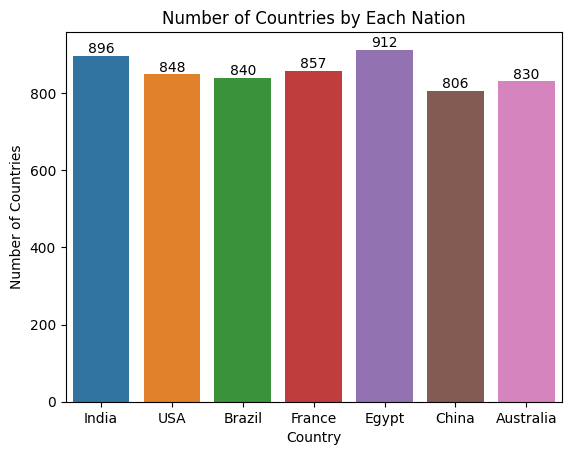

In [ ]:
axis=sns.barplot(x='Country', y='Count', data=data)
axis.bar_label(axis.containers[0])
plt.ylabel('Number of Countries')
plt.title('Number of Countries by Each Nation')
plt.show()

In [ ]:
df.Category.unique()

array(['Nature', 'Historical', 'Cultural', 'Beach', 'Adventure', 'Urban'],
      dtype=object)

In [ ]:
df.Category.value_counts(normalize=True).mul(100).round(2)

Category
Adventure     17.32
Urban         16.80
Cultural      16.66
Beach         16.66
Historical    16.60
Nature        15.96
Name: proportion, dtype: float64

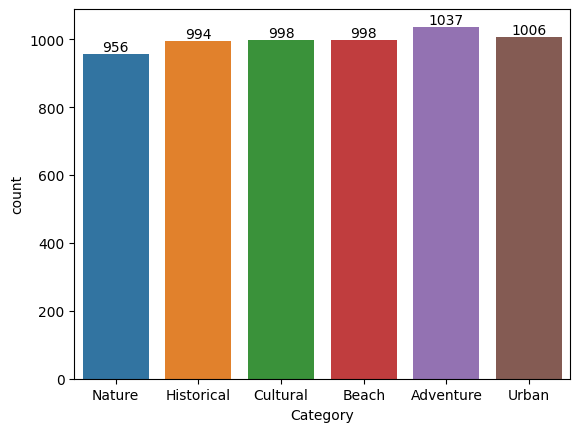

In [ ]:
axis=sns.countplot(data=df , x="Category")
axis.bar_label(axis.containers[0]);

In [ ]:
df.groupby("Country")["Category"].value_counts()

Country    Category  
Australia  Adventure     148
           Beach         148
           Cultural      139
           Historical    134
           Nature        133
           Urban         128
Brazil     Adventure     160
           Historical    148
           Cultural      140
           Urban         140
           Beach         136
           Nature        116
China      Adventure     139
           Cultural      136
           Beach         135
           Historical    135
           Nature        133
           Urban         128
Egypt      Adventure     165
           Historical    157
           Beach         155
           Urban         154
           Cultural      152
           Nature        129
France     Nature        164
           Cultural      148
           Beach         147
           Urban         142
           Historical    132
           Adventure     124
India      Adventure     159
           Beach         153
           Urban         152
           Cultural  

In [ ]:
df.groupby("Country")["Category"].value_counts().unstack()

Category,Adventure,Beach,Cultural,Historical,Nature,Urban
Country,,,,,,
Australia,148,148,139,134,133,128
Brazil,160,136,140,148,116,140
China,139,135,136,135,133,128
Egypt,165,155,152,157,129,154
France,124,147,148,132,164,142
India,159,153,149,147,136,152
USA,142,124,134,141,145,162


In [ ]:
df.Location[df.Category =="Adventure"]

9       pXDJPYzTeU
13      fXEdOCMpsk
22      aVFdQwRuBy
30      XsiJemVocY
37      YNxOOsnhWp
           ...    
5960    ahIRHLEpUE
5961    MoLHwaXDbl
5968    kjadMLXvKB
5969    JCDXHjzueB
5979    SYxoMFmEKW
Name: Location, Length: 1037, dtype: object

In [ ]:
df.Location[(df.Category =="Adventure") & (df.Country=="Australia")]

52      GIYURImcwn
65      VdtaHdliYw
107     oWfVKKcqvw
119     YKYUnegOqN
346     FuISMivFKs
           ...    
5843    QrQzqEjMoq
5853    rrrvfquzHD
5868    ktbOBPtyiz
5932    ctyfGgdmNB
5961    MoLHwaXDbl
Name: Location, Length: 148, dtype: object

In [ ]:
df.Location[(df.Category =="Adventure") & (df.Country=="Brazil")]

142     vpNPWELNCN
214     NkNxyBkOtQ
225     kEbNpBWTjU
228     kVDrEaSkED
238     dhKSDEFePN
           ...    
5803    DfQslhmkUp
5823    BBVFRSASIk
5831    EVKdZahkxs
5834    yLAYExxZvG
5935    rxldZezSaN
Name: Location, Length: 160, dtype: object

In [ ]:
df.Location[(df.Category =="Adventure") & (df.Country=="China")]

143     svVWBsrDyU
218     DumVYqwHuL
307     OFRTYNuxqG
309     nKAIdqvSYO
353     frSGWOREwN
           ...    
5761    KhpchZAVRk
5900    OonTFKtkEX
5905    fexkexEUDR
5931    rnTXrxjQOu
5959    XprLrpQrAH
Name: Location, Length: 139, dtype: object

In [ ]:
df.Location[(df.Category =="Adventure") & (df.Country=="Egypt")]

13      fXEdOCMpsk
64      TYJaKDclZk
74      cebsVIQylz
122     mUWmsuBYlL
178     ETmFAFhKKu
           ...    
5690    eDanOoJDWr
5771    gPRLYnBFoZ
5826    PmppKDxWPx
5884    mBMHxXBGTx
5968    kjadMLXvKB
Name: Location, Length: 165, dtype: object

In [ ]:
df.Location[(df.Category =="Adventure") & (df.Country=="France")]

22      aVFdQwRuBy
90      jdVgKzosKb
154     vXIycbSqWg
262     qfblwFggnL
288     qFAiJLfcoL
           ...    
5531    xTqKuHskJE
5556    nmUYsKPiyk
5605    pXBgWcPFQD
5851    xwhYXxBXwx
5896    mCHJDYgGOu
Name: Location, Length: 124, dtype: object

In [ ]:
df.Location[(df.Category =="Adventure") & (df.Country=="India")]

9       pXDJPYzTeU
37      YNxOOsnhWp
128     zrKgcGqRpk
162     ZaOkXhaLdT
181     dzbjzRHsdy
           ...    
5818    QwoSPpeydX
5890    gWVXCjKuDe
5956    WXUfandjUr
5960    ahIRHLEpUE
5969    JCDXHjzueB
Name: Location, Length: 159, dtype: object

In [ ]:
df.Location[(df.Category =="Adventure") & (df.Country=="USA")]

30      XsiJemVocY
40      meHIIvZxuG
110     uVQAryYqMI
157     GxxgFhfIkT
209     kcMuahswjg
           ...    
5793    PTxIUsaWyX
5812    pMiycaAonp
5873    mxSFTkOsbM
5910    RBbTUBoSVf
5979    SYxoMFmEKW
Name: Location, Length: 142, dtype: object

In [ ]:
print(df['Visitors'].describe())

count      5989.000000
mean     501016.089497
std      289783.294978
min        1108.000000
25%      252789.000000
50%      500831.000000
75%      751371.000000
max      999982.000000
Name: Visitors, dtype: float64


In [ ]:
visitors_by_category = df.groupby('Category')['Visitors'].sum().reset_index()
visitors_by_category

,Category,Visitors
0,Adventure,528962493
1,Beach,495111800
2,Cultural,495834336
3,Historical,495958186
4,Nature,469346177
5,Urban,515372368


In [ ]:
visitors_by_country = df.groupby('Country')['Visitors'].sum().reset_index()
visitors_by_country

,Country,Visitors
0,Australia,416038005
1,Brazil,414293518
2,China,404448372
3,Egypt,458573652
4,France,424944621
5,India,451083005
6,USA,431204187


In [ ]:
visitors_by_country = df.groupby(['Country', "Category"])['Visitors'].sum().reset_index()
visitors_by_country.set_index(['Country', 'Category'], inplace=True)

visitors_by_country

Visitors
Country   Category            
Australia Adventure   75244920
          Beach       74188817
          Cultural    69032021
          Historical  65471017
          Nature      66678786
          Urban       65422444
Brazil    Adventure   83200861
          Beach       67367768
          Cultural    66946542
          Historical  72373269
          Nature      51548460
          Urban       72856618
China     Adventure   68830716
          Beach       66575322
          Cultural    66102278
          Historical  65741695
          Nature      69145197
          Urban       68053164
Egypt     Adventure   82651445
          Beach       81114198
          Cultural    74325882
          Historical  80783975
          Nature      60729979
          Urban       78968173
France    Adventure   60318568
          Beach       69365066
          Cultural    75794317
          Historical  67488451
          Nature      79251754
          Urban       72726465
India     Adventure   82298383
          Beach       74275757
          Cultural    71427451
          Historical  76491148
          Nature      69521390
          Urban       77068876
USA       Adventure   76417600
          Beach       62224872
          Cultural    72205845
          Historical  67608631
          Nature      72470611
          Urban       80276628

In [ ]:
df['Rating'].describe()

count    5989.000000
mean        3.009347
std         1.155980
min         1.000000
25%         2.010000
50%         3.000000
75%         4.010000
max         5.000000
Name: Rating, dtype: float64

In [ ]:
df[df.Rating==df.Rating.max()]

,Location,Country,Category,Visitors,Rating,Revenue,Accommodation_Available
1424,dVRDcWwXMu,China,Urban,720560,5.0,953675.80,Yes
2280,BjKircDVih,China,Nature,545208,5.0,339287.66,No
2780,cGrtbVWCQD,China,Historical,200331,5.0,472193.88,Yes
3261,ybeRbiXvBi,USA,Adventure,64525,5.0,175023.97,Yes
3319,llNplbsNzk,Australia,Cultural,294538,5.0,646748.16,No
3861,vdtIPVkqpn,USA,Beach,550797,5.0,653918.09,No
3889,EjnJCNgDqD,Australia,Nature,200913,5.0,459409.76,No
4236,moIRLKpGRd,Australia,Adventure,989228,5.0,419299.31,No
4524,IvfwPzFIcV,Egypt,Adventure,26686,5.0,989059.13,No
4662,iovMLxwMwA,France,Beach,636272,5.0,384041.13,No


In [ ]:
df[df.Rating==df.Rating.min()]

,Location,Country,Category,Visitors,Rating,Revenue,Accommodation_Available
77,gozxECnEJC,USA,Nature,808255,1.0,627270.04,Yes
587,NOVKVVLHTd,USA,Beach,312912,1.0,183450.14,No
984,gMEKCZRTNP,France,Adventure,111921,1.0,27572.12,Yes
2256,UthTEqjMsz,Australia,Urban,634232,1.0,796925.16,Yes
3616,MFCQRYHTDg,India,Historical,345392,1.0,558781.14,Yes
3734,qjgGjqvhaN,Egypt,Adventure,757107,1.0,185694.95,Yes
3964,cnENAhhCnt,Australia,Nature,542441,1.0,212666.24,No
4005,hTgfyNanPI,USA,Cultural,590896,1.0,296905.64,Yes
4380,dSkpJiqoDK,China,Historical,74635,1.0,546552.31,No
5142,EkLlgyiVwc,France,Beach,290268,1.0,173358.73,No


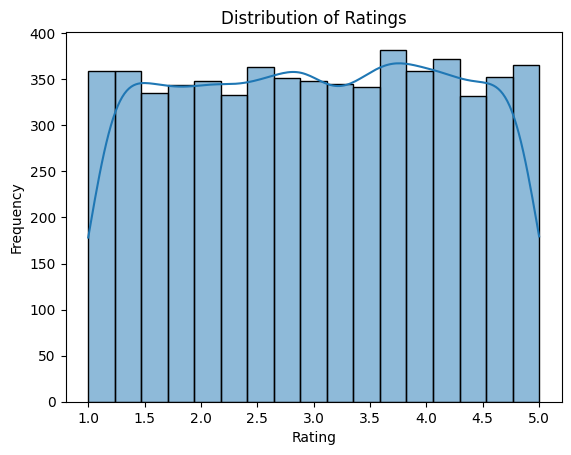

In [ ]:
sns.histplot(df['Rating'], bins=17, kde=True)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

In [ ]:
rating_counts = df['Rating'].value_counts().sort_index()
rating_counts

Rating
1.00    11
1.01    14
1.02    17
1.03    13
1.04     8
        ..
4.96    11
4.97    12
4.98    15
4.99     6
5.00    12
Name: count, Length: 401, dtype: int64

In [ ]:
from math import *
floored_ratings = np.floor(df['Rating']).astype(int)
floored_ratings.unique()

array([1, 2, 3, 4, 5])

In [ ]:
floored_ratings = np.floor(df['Rating']).astype(int)

data = pd.DataFrame({
    'Rating': floored_ratings,
    'Visitors': df['Visitors']
})


data

,Rating,Visitors
0,1,948853
1,2,813627
2,1,508673
3,1,623329
4,1,124867
...,...,...
5984,1,828137
5985,3,276317
5986,3,809198
5987,2,808303


In [ ]:
rating_sum = data.groupby('Rating')['Visitors'].sum().reset_index()
rating_sum

,Rating,Visitors
0,1,728706848
1,2,779688209
2,3,749569766
3,4,737148489
4,5,5472048


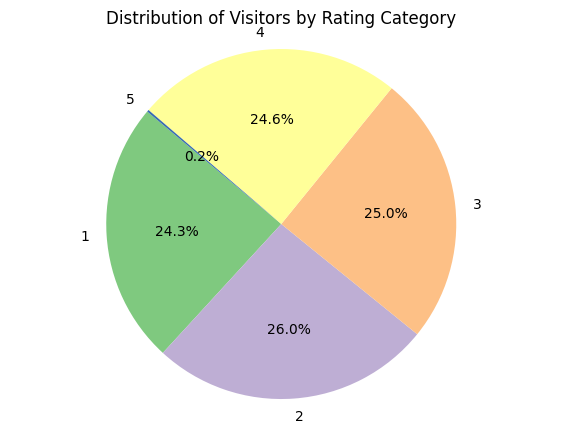

In [ ]:
plt.figure(figsize=(7, 5))
plt.pie(rating_sum['Visitors'], labels=rating_sum['Rating'], autopct='%1.1f%%', startangle=140, colors=plt.cm.Accent.colors)
plt.title('Distribution of Visitors by Rating Category')
plt.axis('equal')  # يجعل الشكل دائري
plt.show()

In [ ]:
correlation_matrix = df[['Revenue', 'Visitors', 'Rating']].corr()
correlation_matrix

,Revenue,Visitors,Rating
Revenue,1.000000,0.008358,0.000574
Visitors,0.008358,1.000000,-0.010337
Rating,0.000574,-0.010337,1.000000


In [ ]:
df['Revenue'].describe()

count      5989.000000
mean     499479.367253
std      286743.225211
min        1025.810000
25%      251410.450000
50%      494169.350000
75%      742241.240000
max      999999.490000
Name: Revenue, dtype: float64

In [ ]:
df[df.Revenue==df.Revenue.min()]

,Location,Country,Category,Visitors,Rating,Revenue,Accommodation_Available
3664,pwszmvbODY,France,Historical,533532,2.25,1025.81,Yes


In [ ]:
df[df.Revenue==df.Revenue.max()]

,Location,Country,Category,Visitors,Rating,Revenue,Accommodation_Available
2705,zQtYCpWsMs,France,Urban,649167,4.69,999999.49,No


In [ ]:
revenue_per_country = df.groupby('Country')['Revenue'].sum().reset_index()
revenue_per_country


,Country,Revenue
0,Australia,4.126633e+08
1,Brazil,4.267832e+08
2,China,3.984324e+08
3,Egypt,4.605948e+08
4,France,4.105266e+08
5,India,4.546763e+08
6,USA,4.277053e+08


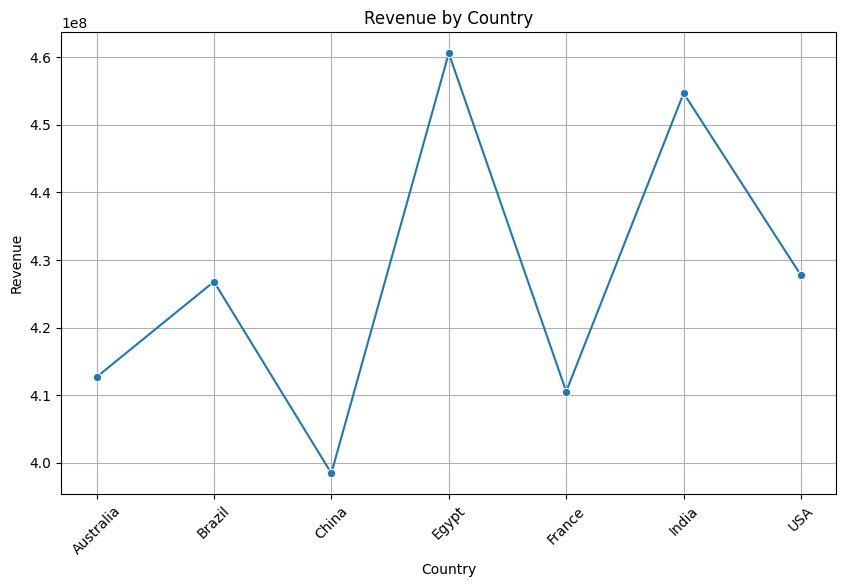

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(x='Country', y='Revenue', data=revenue_per_country, marker='o')

plt.title('Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45) 
plt.grid(True)
plt.show()


In [ ]:
revenue_per_Category = df.groupby('Category')['Revenue'].sum().reset_index()
revenue_per_Category


,Category,Revenue
0,Adventure,5.021662e+08
1,Beach,4.972478e+08
2,Cultural,5.181320e+08
3,Historical,4.846126e+08
4,Nature,4.772601e+08
5,Urban,5.119633e+08


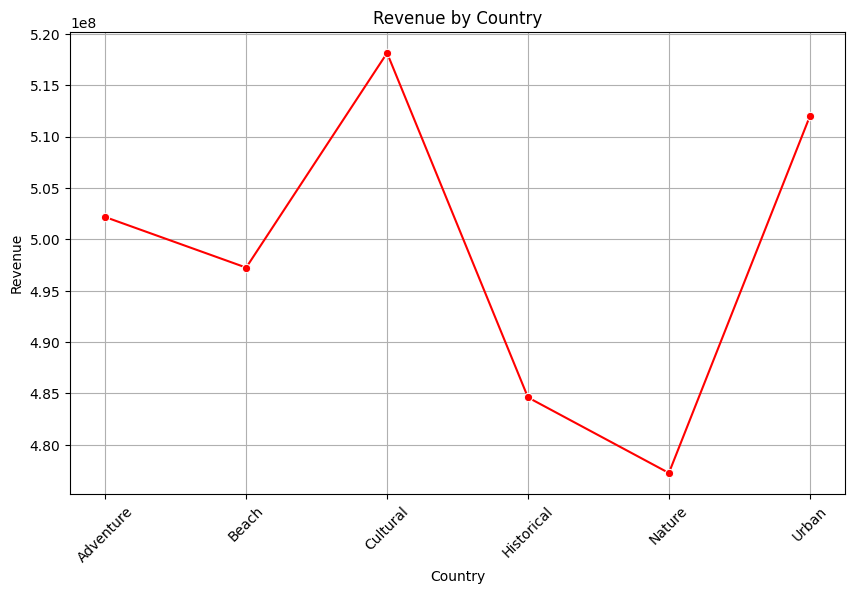

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(x='Category', y='Revenue', data=revenue_per_Category, marker='o',color="red")

plt.title('Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45) 
plt.grid(True)
plt.show()


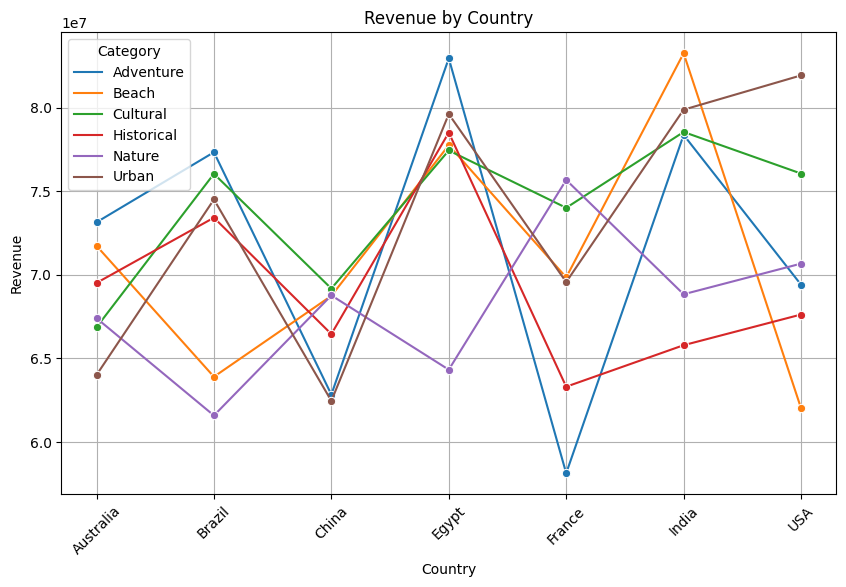

In [ ]:
revenue_per_country = df.groupby(['Country',"Category"])['Revenue'].sum().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(x='Country', y='Revenue',hue="Category", data=revenue_per_country, marker='o')

plt.title('Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45) 
plt.grid(True)
plt.show()


In [ ]:
revenue_per_category = df.groupby(['Country', 'Category'])['Revenue'].sum().reset_index()
revenue_per_category.set_index(['Country', 'Category'], inplace=True)
revenue_per_category

Revenue
Country   Category               
Australia Adventure   73143074.22
          Beach       71734255.42
          Cultural    66860675.16
          Historical  69513402.10
          Nature      67405458.04
          Urban       64006467.32
Brazil    Adventure   77333822.40
          Beach       63899164.12
          Cultural    76042841.46
          Historical  73418486.47
          Nature      61582499.48
          Urban       74506386.34
China     Adventure   62835395.80
          Beach       68741200.34
          Cultural    69177870.10
          Historical  66453400.60
          Nature      68768453.44
          Urban       62456057.97
Egypt     Adventure   82950318.40
          Beach       77755196.13
          Cultural    77438684.31
          Historical  78510790.60
          Nature      64323505.07
          Urban       79616298.02
France    Adventure   58126792.90
          Beach       69845116.72
          Cultural    74008400.22
          Historical  63304545.83
          Nature      75674952.86
          Urban       69566833.74
India     Adventure   78370335.87
          Beach       83256415.38
          Cultural    78545467.98
          Historical  65788358.97
          Nature      68835947.02
          Urban       79879774.13
USA       Adventure   69406465.01
          Beach       62016423.75
          Cultural    76058080.68
          Historical  67623602.79
          Nature      70669239.05
          Urban       81931474.27

In [ ]:
df['Accommodation_Available'].value_counts()

Accommodation_Available
Yes    3013
No     2976
Name: count, dtype: int64

<Axes: ylabel='count'>

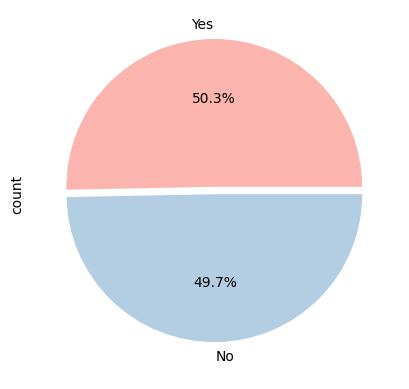

In [ ]:
colors = plt.get_cmap('Pastel1').colors
df['Accommodation_Available'].value_counts().plot(kind="pie", autopct='%1.1f%%', colors=colors, explode=(0.05 , 0))

In [ ]:
stats = df.groupby('Accommodation_Available')['Revenue'].describe()
stats

,count,mean,std,min,25%,50%,75%,max
Accommodation_Available,,,,,,,,
No,2976.0,500830.503891,285201.423110,1227.89,258196.7125,491006.175,746675.0475,999999.49
Yes,3013.0,498144.822735,288299.120411,1025.81,245450.5300,499234.780,737726.3800,999821.20


In [ ]:
df.groupby('Accommodation_Available')['Revenue'].sum().reset_index()


,Accommodation_Available,Revenue
0,No,1.490472e+09
1,Yes,1.500910e+09


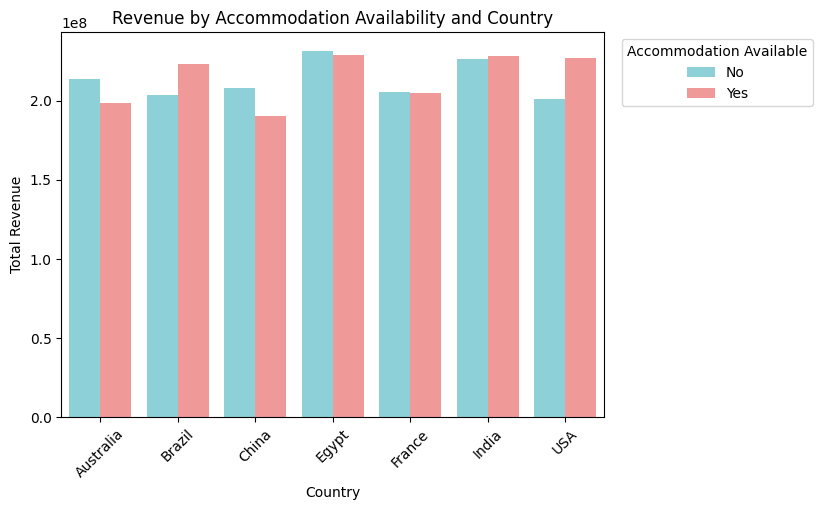

In [ ]:
revenue_by_accommodation_country = df.groupby(['Accommodation_Available', 'Country'])['Revenue'].sum().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=revenue_by_accommodation_country, x='Country', y='Revenue', hue='Accommodation_Available', palette=["#81DAE3" , "#FF8A8A"])
plt.title('Revenue by Accommodation Availability and Country')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.legend(title = "Accommodation Available", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

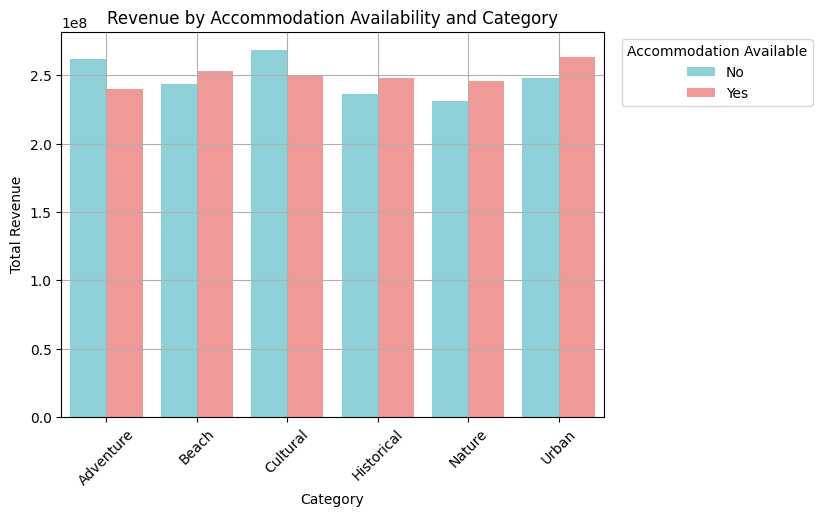

In [ ]:
revenue_by_accommodation_category = df.groupby(['Accommodation_Available', 'Category'])['Revenue'].sum().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=revenue_by_accommodation_category, x='Category', y='Revenue', hue='Accommodation_Available', palette=["#81DAE3" , "#FF8A8A"])
plt.title('Revenue by Accommodation Availability and Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.legend(title = "Accommodation Available", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.grid(True)
plt.show()

In [ ]:
df_Egypt =df.Location[(df.Country =="Egypt") & (df.Accommodation_Available == "Yes")]
for location in df_Egypt:
    print(location,end=" ,  ")

IKdhVWFKRc ,  FOEgDMzluS ,  OWwgRpSeNj ,  asIaWBjFAf ,  DtRiOtXlOT ,  cebsVIQylz ,  zrvsAldpws ,  SmkajIHvrA ,  ZWKShywvrU ,  TlrDolHdpl ,  bFBoalAcRW ,  QzYTxhcxti ,  gdIkaBzpyJ ,  pnejoUGcUx ,  qbQUpweTcC ,  xolQKxHggX ,  UNnDYEwhXz ,  SJQkRVBekM ,  kEZAfaEXSH ,  LgKeRLsqpk ,  CbMQsNdMwN ,  ANWyZwqIlY ,  nfZZDrEVCs ,  MYeUrLkikD ,  XaEkfUeopT ,  sjqxIQHwzW ,  SxQrfqMYBC ,  kxGIJKtCpU ,  RKCvHVkRIZ ,  QvoQwzIVft ,  gOGrsNHCRu ,  erFCFZEJfY ,  yviCCotwgL ,  lPQftFwLiM ,  smMjeQIMEa ,  fIuwlSPCud ,  fPrTVCEvVZ ,  mRamfeVrGK ,  UFJEfROFma ,  WiTQmCHwnT ,  oujDSeKQPa ,  quKByLfTrS ,  GFOIXDYcjx ,  hWVpZaWjPT ,  IqYCOGHdcU ,  UHOapEemot ,  RYKZaIvtid ,  gRIPgdkrUM ,  YmbbytNUcA ,  heBzroWkIT ,  ExmGSRRWAZ ,  VtfIvHdtUJ ,  kstANZoqBx ,  pwAzGJgiWQ ,  MNumQhCyxc ,  NYQkFlvjcs ,  PjQZCBKVuw ,  NJsuerAfxv ,  qLVUimrewX ,  FWPfZENkiG ,  KAwoMgcEMY ,  RvmkpbzcSJ ,  LBRtcRRQsX ,  GsvdqNpfcY ,  HYhRJTNRIm ,  tbhFgqjjYA ,  OQeeLpHKUV ,  geWKYgvgGz ,  kqzYmnkQuQ ,  pvEriZZhjv ,  ECXfuvTppO ,  uKdevC

In [ ]:
# حفظ البيانات بعد التنظيف في ملف جديد
df.to_csv(r"C:\Users\Abdullah\Desktop\project NLP\data& preprocessing\tourism_cleaned.csv", index=False)

In [ ]:
x="London"
print(x.startswith("Lo"))